## Libraries

In [62]:
using KadanoffBaym, LinearAlgebra, BlockArrays
using Bessels
using PyPlot
using Tullio
⊗(A,B) = kron(A,B)

⊗ (generic function with 1 method)

## Parameters and predifined quantities

In [63]:
hbar = 1.#0.658211928e0  
### Pauli matrices
σ_0 = Matrix{ComplexF64}([1. 0. ; 0 1])
σ_x =  Matrix{ComplexF64}([0 1; 1 0])
σ_y =  Matrix{ComplexF64}([0 -1im ; 1im 0 ])
σ_z = Matrix{ComplexF64}([1 0. ; 0. -1]) ; 

In [64]:
# Lattice size
L = 2
nσ = 2
nx = L
ny = 1
γ = 1.0
γc = 1.0#1.0
γso = 0
j_sd = 0.1
ϵ_wbl = 0.0
Temp = 300
#KB
# Allocate the initial Green functions (time arguments at the end)
GL = GreenFunction(zeros(ComplexF64, nx*nσ, nx*nσ, 1, 1), SkewHermitian)
GG = GreenFunction(zeros(ComplexF64, nx*nσ, nx*nσ, 1, 1), SkewHermitian);
#Ht = GreenFunction(zeros(ComplexF64, nx*nσ, nx*nσ, 1, 1), SkewHermitian);
# GL_d = GreenFunction(zeros(ComplexF64, L, L, 1, 1), SkewHermitian)
# GG_d = GreenFunction(zeros(ComplexF64, L, L, 1, 1), SkewHermitian);

In [65]:
I_a1b1 = Matrix{ComplexF64}(I, L, L)           # Identity on lattice space
I_ab = Matrix{ComplexF64}(I, nσ*L, nσ*L)        # Identity on lattice ⊗ spin
# --- Pauli matrices extended to the full Hilbert space ---
σ_x1ab = kron(I_a1b1, σ_x)
σ_x2ab = kron(I_a1b1, σ_y)
σ_x3ab = kron(I_a1b1, σ_z)
# --- Pauli matrices as a 3D array σ_abx[μ, i, j] ---
σ_ijx = cat(σ_x1ab, σ_x2ab, σ_x3ab; dims=3) ;

### Auxiliary integrator

In [66]:
function integrate0(t1,t2,A)
    retval = 0.0
    dt = 0.01
    ts = t2:dt:t1
    A_vec = A.(ts)
    @tullio retval = A_vec[α]
    retval = retval*dt
end
# Auxiliary integrator for the first type of integral
function integrate1(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t1)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:tmax
        @views LinearAlgebra.mul!(retval, A[t1, k] - B[t1, k], C[k, t2], hs[k], 1.0)
    end
    return retval
end
# Auxiliary integrator for the second type of integral
function integrate2(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t2)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:tmax
        @views LinearAlgebra.mul!(retval, A[t1, k], B[k, t2] - C[k, t2], hs[k], 1.0)
    end
    return retval
end

integrate2 (generic function with 1 method)

### Precesion 

In [67]:
mutable struct PrecSpin
    """ This mutable structure act like a class 
    in python, it defines an object with the 
    characteristics of a precessing spin
    """
    i::Int64 #   
    axis_phi::Float64 
    axis_theta::Float64 
    phi_zero::Float64 
    theta_zero::Float64 
    start_time::Float64 
    T::Float64 
    s::Vector{Float64} 
    ### Initial values of PrecSpin .
    function PrecSpin(i=0,axis_phi=0.0,axis_theta=0.0,
            phi_zero=0.0,theta_zero=0.0,start_time=0.0
            ,T=1.,s=[0.,0.,1.])
        new(i,axis_phi,axis_theta,phi_zero,theta_zero,start_time,T,s)
    end
end

function update!(this::PrecSpin, time  )
    """ This function  update the magnetic moment associated
    to the mutable structure PrecSpin 
    
    parameters:
    ----------
    this: mutable structure 
    contain an structure with the characteristics of a spin 
    time: Float64
    time where the spin is evaluated 
    
    returns:
    -------
    Update the strucure associated to a  precessing spin 
    """
    if time >= this.start_time
        t = time - this.start_time
    else
        t = 0.0
    end
    omega = 2*pi / this.T
    otheta = pi*this.theta_zero/180.
    ophi = pi*this.phi_zero /180. ##########
    # compute spin position for precession along the z-axis
    sz = cos(otheta)
    sx = cos(ophi + omega*t)*sin(otheta)
    sy = sin(ophi + omega*t)*sin(otheta)
    # Now rotate along y 
    atheta = pi * this.axis_theta/ 180.
    aphi = pi * this.axis_phi / 180. 
    sx = sx*cos(atheta) - sz* sin(atheta)
    sz = sx* sin(atheta) + sz*cos(atheta)
    # No rotate along the z 
    sx = sx*cos(aphi) + sy*sin(aphi)
    sy = -sx*sin(aphi) + sy*cos(aphi)
    this.s .= [sx, sy, sz]
    nothing
end

update! (generic function with 1 method)

## Self Energy 

In [68]:
#### Dynamical variables 
Base.@kwdef struct FermiHubbardData2B{T}
    GL::T
    GG::T
    ΣL::T # zero(GL)
    ΣG::T # zero(GG)
    ##Ht::T
end

In [69]:
#### Calculation of the self-energy 
function selfenergy(ϵ;γ=γ,γc=γc)# thop = thop, t_ls = 1.) 
    ### Note that this configuration for the self energy can be modified later
    #thop = global_var.thop
    Δ = 4 * γ^2 - ϵ^2
    if real(Δ) > 0
        Σ = ϵ - im * sqrt(Δ)
    else
        if real(ϵ) > 0
            sgn = 1
        else
            sgn = -1
        end
        Σ = ϵ - sgn * sqrt(-Δ)
    end
    Σ = Σ* (γc^2 / (2 * γ^2))
    return Σ
end
function Gamma_ϵ(ϵ;γ=γ,γc=γc)#
    -2*imag(selfenergy(ϵ;γ=γ,γc=γc))
end
#using Bessels
function Gamma_t(t;γ=γ,γc=γc)#
    γ^2/(γc^2)*γ^2*(besselj(0, 2*γ*t)+ besselj(2, 2*γ*t))#*exp(1im*μ*t)
    #-2*imag(selfenergy(ϵ;γ=γ,γc=γc))
end
function Gamma2_t(t;γ=1,γc=1.)#
    retval = 0.0
    dϵ = 0.001
    ϵs = -3γ:dϵ:3γ
    Gamma = Gamma_ϵ.(ϵs;γ,γc)
    e = exp.(-1im*ϵs*t)
    @tullio retval = Gamma[α]*e[α]
    retval = retval*dϵ/2pi#/(length(ϵs))
end
function fermi_mu(ϵ; μ=0.0, Temp=Temp)
    KB = 8.6173324e-5           ### Bolzmann factor
    β = 1/(KB*Temp)#1.0
   1/(1. + exp((ϵ-μ)*β  ))   #/(KB*Temp)
end
function SelfL(t;γ=γ,γc=γc)
    retval = 0.0
    dϵ = 0.001
    ϵs = -3γ:dϵ:3γ
    Gamma = Gamma_ϵ.(ϵs*0.0;γ,γc) #### NOTE WBL
    e = exp.(-1im*ϵs*t)
    f = fermi_mu.(ϵs)
    @tullio retval = Gamma[α]*e[α]*f[α]
    retval = 1im*retval*dϵ/2pi
end
function SelfG(t;γ=γ,γc=γc)
    retval = 0.0
    dϵ = 0.001
    ϵs = -3γ:dϵ:3γ
    Gamma = Gamma_ϵ.(ϵs*0.0;γ,γc) #### NOTE WBL
    e = exp.(-1im*ϵs*t)
    f = -fermi_mu.(ϵs) .+ 1
    @tullio retval = Gamma[α]*e[α]*f[α]
    retval = -1im*retval*dϵ/2pi
end
function SelfL_WBL(t;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl)
    # if t ≈ 0.0
    #     SelfL = 1im*imag(1im*Gamma_ϵ(ϵ_wbl;γ,γc)*exp(-1im*ϵ_wbl*t)*fermi_mu(ϵ_wbl))
    #     else
    #     SelfL = 0.0
    # end
    # σ = 0.5
    # delta_gauss = (1/(σ*sqrt(2pi)))*exp(0.5*t^2 / σ^2 )
    SelfL = 1im*imag(1im*Gamma_ϵ(ϵ_wbl;γ,γc)*exp(-1im*ϵ_wbl*t)*fermi_mu(ϵ_wbl))
    return SelfL
end
function SelfG_WBL(t;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl)
    # if t ≈ 0.0
    #    SelfG = 1im*imag(-1im*Gamma_ϵ(ϵ_wbl;γ,γc)*exp(-1im*ϵ_wbl*t)*(-fermi_mu(ϵ_wbl) + 1))
    #     else 
    #     SelfG = 0.0
    # end
    # σ = 0.5
    # delta_gauss = (1/(σ*sqrt(2pi)))*exp(0.5*t^2 / σ^2 )
    SelfG = 1im*imag(-1im*Gamma_ϵ(ϵ_wbl;γ,γc)*exp(-1im*ϵ_wbl*t)*(-fermi_mu(ϵ_wbl) + 1))
    return SelfG
end

    ### Add sharp dependency on the integral 
    
    

SelfG_WBL (generic function with 1 method)

In [70]:

# plt.plot(ϵs,fermi_mu.(ϵs))


In [71]:
#Gamma_ϵ(0.0;γ=1,γc=1.)
# σ = 0.02
# delta_gauss = (1/(σ*sqrt(2pi)))*exp(0.5*0.01^2 / σ^2 )

In [72]:
#fermi_mu(0.0)
#ϵs = -25:0.1:25

#plt.plot(ϵs,Gamma_ϵ.(ϵs;γ=10))

In [73]:
#1im≈1.00000001im
#1==1.00000001
# if 1==2
#     a=0.0
#     else
#         a=2
# end
# a
#imag(1im)
#SelfG_WBL(0.0)

In [74]:
#SelfL_WBL(0.0)
#SelfL(0.0;γ=1.0,γc=1.0)

In [75]:
stepp(t;ti=10) = t < ti ? sin((pi/2)*t/ti)^2 : 1

stepp (generic function with 1 method)

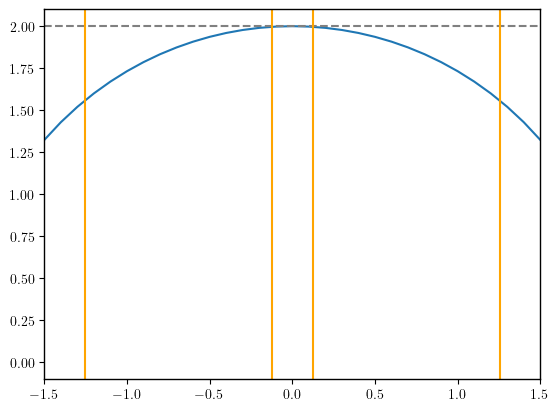

(-1.5, 1.5)

In [76]:
# Gamma2_t(0.1)
# 1/(2*pi*0.1)
# ϵs = -4:0.1:4
# length(ϵs)
# ts= 0.1:0.1:50
# # plot(ts,Gamma_t.(ts))
# # plot(ts,Gamma2_t.(ts)/2)
# plot(ts,SelfL.(ts))
# plt.ylim(-0.1,0.1)

es=-4:0.1:4
# # # plot(es,real(selfenergy.(es)))
# # # plot(es,imag(selfenergy.(es)))
plot(es,Gamma_ϵ.(es))
#plt.ylim(2-0.5,2+0.5)
plt.axhline(2,color="gray",ls="--")
plt.axvline(2pi/5,color="orange")
plt.axvline(-2pi/5,color="orange")
plt.axvline(-2pi/50,color="orange")
plt.axvline(2pi/50,color="orange")
plt.xlim(-1.5,1.5)
# SelfG(0)
#2pi/5

In [78]:
# Callback function for the self-energies #### This function includes the modifcation in time of the general equations of motion 

function self_Lead!(model,data,times,_,_,t,t′)
    # Unpack data and model 
    (;GL,GG,ΣL,ΣG) = data
    (;hss, Δ1, Δ2) = model
    ∫ds(A) = integrate0(times[t],times[t′], A  ) 
    # Resize self energies 
    if (n = size(GL,3)) > size(ΣL,3)
        resize!(ΣL, n)
        resize!(ΣG, n)
        ##resize!(Ht, n)
    end
    D2 = Matrix{ComplexF64}(I, nσ, nσ)
    ### Time dependece of the leads 
    ϕ1_t = ∫ds(Δ1)#Δ1(times[t], times[t′] )
    ϕ2_t = ∫ds(Δ2)
    #Δ2_t = Δ2(times[t], times[t′] )
    ### Setting the component of the left self-energy
    # SelfG0_WBL=1im*imag(SelfG_WBL(0.0;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl))
    # SelfL0_WBL=1im*imag(SelfL_WBL(0.0;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl))

    
    self = SelfL(times[t] - times[t′];γ=1.0,γc=1.0) ################### note the limit
    #SelfL_WBL(times[t] - times[t′];γ=γ,γc=γc,ϵ_wbl = ϵ_wbl)
    #SelfL(times[t] - times[t′];γ=1.0,γc=1.0)
    selfL0 = zeros(ComplexF64,L*nσ,L*nσ)
    selfL0[1:nσ,1:nσ] = self*exp(-1im*ϕ1_t)*D2#diagm(ones(nσ))### Left lead selfenergy 
    selfL0[end-nσ+1:end,end-nσ+1:end] = self*exp(-1im*ϕ2_t)*D2#diagm(ones(nσ)) ### Right lead selfenergy 
    ### Setting the component of the right self-energy
    self = SelfG(times[t] - times[t′];γ=1.0,γc=1.0)
    #SelfG_WBL(times[t] - times[t′];γ=γ,γc=γc,ϵ_wbl = ϵ_wbl)
    selfG0 = zeros(ComplexF64,L*nσ,L*nσ)
    selfG0[1:nσ,1:nσ] = self*exp(-1im*ϕ1_t)*D2#diagm(ones(nσ)) ### Left lead selfenergy 
    selfG0[end-nσ+1:end,end-nσ+1:end] = self*exp(-1im*ϕ2_t)*D2#diagm(ones(nσ)) ### Right lead selfenergy 
    ### Setting the time dependence of the hamiltonian 
    #########-------------------------------------------------------------------------------############
    ###Ht[t,t] =  hss(times[t])

    # SelfG0_WBL=1im*imag(SelfG_WBL(0.0;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl))
    # SelfL0_WBL=1im*imag(SelfL_WBL(0.0;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl))
    #hs_t(times[t])
    ### Define the self energies 
    ΣL[t, t′] = selfL0*stepp.(times[t];ti=40)*stepp.(times[t′];ti=40)#exp()
    #println(ΣL[t, t′])
    ΣG[t, t′] = selfG0*stepp.(times[t];ti=40)*stepp.(times[t′];ti=40)
end

self_Lead! (generic function with 1 method)

In [79]:
#SelfL(0.0;γ=1,γc=1.)

function hs_t(t)
    theta_1, phi_1 = 20.0 , 0.0#45.0, 0.0 
    period = 5 
    pr_spins = [PrecSpin(i) for i in 1:1:L  ]        ### array with mutables object of preccesin spins
    for jj in 1: L
        pr_spins[jj].i = jj ## lattice site 
        pr_spins[jj].theta_zero = theta_1
        pr_spins[jj].axis_phi = phi_1
        pr_spins[jj].T = period 
        #println(pr_spins[jj].i)
    end
    vm_i1x = zeros(Float64,nx*ny,3)
    for j in 1:1:nx #3:1:5#n_precessing#length(pr_spins)
        #println(j)
        #dv.vm_i1x[2,:] .= zeros(Float64,3)
        update!(pr_spins[j], t )
        vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
        #println(vm_i1x)
    end   
    #########-------------------------------------------------------------------------------############
    ### Define the Hamiltonian 
    hs(vm_i1x;nx=nx,ny=ny,γ=γ,γso=γso,j_sd=j_sd)
end

hs_t (generic function with 1 method)

In [80]:
#hs_t(0)

## Hamiltonian 

In [81]:
############# Building Hamiltonian
#### Create electronic Hamiltonian 
function block_h(;ny=ny,γ=γ,γso=γso)
    #γ::Float64,γso::ComplexF64,Bz::Float64,ny::Int)
    "Creates the building blocks for a general nx x ny square lattice "
    dim = ny*2 # We include the spin degree of freedom 
    ######
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' #-Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end

function hs(vm_i1x::Array{Float64,2};nx=nx,ny=ny,γ=γ,γso=γso,j_sd=j_sd)
    "This function build the central hamiltonian wwith two band"
    #γ::Float64,γso::ComplexF64,Bz::Float64,nx::Int,ny::Int)
    dim = nx*ny*2 #*2
    zero = zeros(ComplexF64,nx,nx)
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = block_h(;ny,γ,γso)
    Tx = diagm( -1 =>  ones(nx-1))⊗T 
    HC = (One_x⊗H0) +  Tx + Tx'
    ### Local moments
    for i in range(1,nx) 
        zero[i,i] = 1.0
        HC += -j_sd*zero⊗(vm_i1x[i,1]*σ_x
                    +vm_i1x[i,2]*σ_y
                    +vm_i1x[i,3]*σ_z)
        zero[i,i] = 0.0
    end
    return HC
end


hs (generic function with 1 method)

In [82]:
# theta_1, phi_1 = 20.0 , 0.0#45.0, 0.0 
# period = 5.0 
# pr_spins = [PrecSpin(i) for i in 1:1:2  ]        ### array with mutables object of preccesin spins
# for jj in 1: 2
# pr_spins[jj].i = jj ## lattice site 
# pr_spins[jj].theta_zero = theta_1 
# pr_spins[jj].phi_zero = phi_1 
# pr_spins[jj].T = period 
# #println(pr_spins[jj].i)
# end
# for j in 1:1:2 #3:1:5#n_precessing#length(pr_spins)
# update!(pr_spins[j], 0.0 )
# vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
# end   

####------------ Dynamical variables--------#########
#### Electronic hamiltonians 
# hs_ij = hs(vm_i1x;nx,ny,γ,γso,j_sd)#::Array{ComplexF64,2} 
# e, psi = eigen(hs_ij)
# rho_0=psi[:,1]*psi[:,1]'


In [83]:
#vm_i1x

In [84]:
#### Auxiliary structure with the parameters of the model 
Base.@kwdef struct FermiOpenModel{T1,T2,T3}
    # interaction strength
    # Time dependence of the self energies 
    Δ1::T1
    Δ2::T2
    #U::T
    nx = nx
    ny = ny
    nσ = nσ
    γ = γ
    γso =  γso
    j_sd = j_sd
    # Initial configuration of the classical vectors 
    #vm_i1x = vm_i1x#zeros(Float64,  nx, 3)
    #vm_i1x = zeros(Float64,  L, 3);
    # Hamiltonian of the system 
    hss::T3 
    #hs(vm_i1x;nx,ny,γ,γso,j_sd)
    #H_u = h
    #H_d = h
end

#model.Δ2

## Initial conditions 

In [85]:
### Leviton 
# ts = 0.0:0.1:200
# τ = 6
# t0 = 80
# A = 0.5
# lev(t;t0 = t0,τ = τ) = 2τ/((t-t0)^2+τ^2)
# gauss(t;A=A,t0=t0,τ=τ)=A*exp(-(t-t0)^2/(2*τ^2))
# plt.plot(ts,lev.(ts))
# plt.plot(ts,gauss.(ts))
#model.hs

In [86]:
#Δ1 = t1-> lev(t1;t0 = t0,τ = τ)
#N

In [87]:
# Initial conditions
# τ = 1.0#6
# t0 = 50
# A = 0.5
# Relatively small interaction parameter
U₀ = 0.0
U₁ = 0.0 #0.05
#model = FermiOpenModel(Δ1 = t1-> lev(t1;t0 = t0,τ = τ) ,Δ2 = t2-> U₁)
model = FermiOpenModel(Δ1 = t1-> U₀ ,Δ2 = t2-> U₁,hss = t1->hs_t(t1))
N = zeros(L*nσ)
##################################################################### Partitioned Eq
vm_i1x = zeros(Float64,  L, 3)
theta_1, phi_1 = 20.0 , 0.0#45.0, 0.0 
period = 5.0 
pr_spins = [PrecSpin(i) for i in 1:1:2  ]        ### array with mutables object of preccesin spins
for jj in 1: 2
    pr_spins[jj].i = jj ## lattice site 
    pr_spins[jj].theta_zero = theta_1 
    pr_spins[jj].phi_zero = phi_1 
    pr_spins[jj].T = period 
#println(pr_spins[jj].i)
end
for j in 1:1:2 #3:1:5#n_precessing#length(pr_spins)
    update!(pr_spins[j], 0.0 )
    vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
end  
Gls_ij = zeros(ComplexF64, (4,4) );
hs_ij = hs(vm_i1x;nx,ny,γ,γso,j_sd)#::Array{ComplexF64,2} 
ε₂, U₂ = eigen(hs_ij)
f₂ = fermi_mu.((ε₂))
### it is in termal equilibrium
Gls_ij .= 1im * (U₂ * Diagonal(f₂) * U₂')
####################################################################
# N_d = zeros(L)
# #######
#N[1:4] = 1.0 .* [1.0, 1.0,1.0 , 1.0]*0.0
# N_d[1:4] = 0.1 .* [1, 1, 1, 1]
# #######
# N_u[5:8] = 0.0 .* [1, 1, 1, 1]
# N_d[5:8] = 0.0 .* [1, 1, 1, 1]
# #######
# GL[1, 1] = 1.0im * diagm(N) #rho_0#
# GG[1, 1] = -1.0im * (I - diagm(N)) ; #rho_0)
GL[1, 1] = Gls_ij # 1.0im * diagm(N)#
GG[1, 1] = -1.0im*I + Gls_ij#-1.0im * (I - diagm(N)) ; #
ΣL = zero(GL)
ΣG = zero(GG)
D2 = Matrix{ComplexF64}(I, L*nσ, L*nσ)
ΣL[1,1] =  SelfL(0;γ=1.0,γc=1.0)*D2
#SelfL_WBL(0.0;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl)*D2#*0.1#diagm(ones(L*nσ))
ΣG[1,1] = SelfG(0;γ=1.0,γc=1.0)*D2
#SelfG_WBL(0.0;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl)*D2#*0.1#diagm(ones(L*nσ))
#Ht[1,1] = hs(vm_i1x;nx,ny,γ,γso,j_sd)
#2pi/5
data = FermiHubbardData2B(GL=GL, GG=GG, ΣL=ΣL, ΣG=ΣG);#,Ht=Ht) ;
#Ht[2,2]
#SelfL(0;γ=1.0,γc=1.0)
#SelfL(0;γ=1.0,γc=1.0)

FermiHubbardData2B{GreenFunction{ComplexF64, 4, Array{ComplexF64, 4}, SkewHermitian}}(ComplexF64[0.0 + 0.5000000000000001im 0.0 - 8.095204053071943e-17im 0.0 + 0.4999999999999995im 0.0 - 7.204030419973748e-17im; 0.0 - 8.440727267158066e-17im 0.0 + 0.49999999999999956im 0.0 - 1.6173964595448435e-16im 0.0 + 0.49999999999999956im; 0.0 + 0.4999999999999995im 0.0 - 1.582844138136231e-16im 0.0 + 0.5000000000000002im 0.0 + 1.10359606011684e-16im; 0.0 - 7.549553634059869e-17im 0.0 + 0.49999999999999956im 0.0 + 1.0690437387082277e-16im 0.0 + 0.4999999999999996im;;;;], ComplexF64[0.0 - 0.4999999999999999im 0.0 - 8.095204053071943e-17im 0.0 + 0.4999999999999995im 0.0 - 7.204030419973748e-17im; 0.0 - 8.440727267158066e-17im 0.0 - 0.5000000000000004im 0.0 - 1.6173964595448435e-16im 0.0 + 0.49999999999999956im; 0.0 + 0.4999999999999995im 0.0 - 1.582844138136231e-16im 0.0 - 0.4999999999999998im 0.0 + 1.10359606011684e-16im; 0.0 - 7.549553634059869e-17im 0.0 + 0.49999999999999956im 0.0 + 1.06904373870

## EOMS

In [88]:
# Right-hand side for the "vertical" evolution
function fv!(model, data, out, times, h1, h2, t, t′)
    #### NOTE THAT ANY EXTERNAL TIME DEPENDENCE OF THE FUNCTIONS
    #### SHOULD BE INCLUDED IN AN EXTERNAL CALLBACK FUNCTIONS 
    # Unpack data and model
    (; GL, GG, ΣL, ΣG) = data
    (; hss, Δ1, Δ2) = model ### How to modify the Hamiltonian to include the time dependence 
    # Real-time collision integrals
    ∫dt1(A, B, C) = integrate1(h1, t, t′, A, B, C)
    ∫dt2(A, B, C) = integrate2(h2, t, t′, A, B, C)
    H = hss(times[t] )
    # SelfG0_WBL=1im*imag(SelfG_WBL(0.0;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl))*stepp.(times[t];ti=30)^2
    # SelfL0_WBL=1im*imag(SelfL_WBL(0.0;γ=γ,γc=γc,ϵ_wbl = ϵ_wbl))*stepp.(times[t];ti=30)^2
    # Equations of motion
    out[1] = -1.0im * ( H* GL[t, t′] +
        ∫dt1(ΣG, ΣL, GL) + ∫dt2(ΣL, GL, GG))
        #+ (SelfG0_WBL -SelfL0_WBL)*GL[t, t′] + SelfL0_WBL*(GL[t, t′]-GG[t, t′]) )
        #∫dt1(ΣG, ΣL, GL) + ∫dt2(ΣL, GL, GG)) #### For G<
        
    
    out[2] = -1.0im * (H* GG[t, t′] +
        ∫dt1(ΣG, ΣL, GG) + ∫dt2(ΣG, GL, GG))
        #+(SelfG0_WBL -SelfL0_WBL)*GG[t, t′] + SelfG0_WBL*(GL[t, t′]-GG[t, t′]) )
        #∫dt1(ΣG, ΣL, GG) + ∫dt2(ΣG, GL, GG)) #### For G>
    #println(H)
    return out
end
# Right-hand side for the "diagonal" evolution
# function fd!(model, data, out, times, h1, h2, t, t′)
#     fv!(model, data, out, times, h1, h2, t, t)
#     out[1] .-= adjoint.(out[1])
#     out[2] .-= adjoint.(out[2])
# end
# # Right-hand side for the "diagonal" evolution
# function fd!(model, data, out, times, h1, h2, t, t′)
#     fv!(model, data, out, times, h1, h2, t, t)
#     out .-= adjoint.(out)
# end
function fd!(model, data, out, times, h1, h2, t, t′)
    fv!(model, data, out, times, h1, h2, t, t)
    out[1] .-= out[1]'
    out[2] .-= out[2]'
end

fd! (generic function with 1 method)

## Evolution

In [27]:
#SelfG_WBL(0) -SelfL_WBL(0)

In [28]:
#conjugate()

In [29]:
# # final time
# tmax = 80#120#20#100#80

# # tolerances
# atol = 1e-7#1e-8#1e-7#
# rtol = 1e-6#1e-6#1e-4#

# # Call the solver
# elapsed_time = @elapsed begin
# sol = kbsolve!(
#     (x...) -> fv!(model, data, x...),
#     (x...) -> fd!(model, data, x...),
#     [data.GL, data.GG],
#     (0.0, tmax);
#     callback = (x...) -> self_Lead!(model, data, x...),
#     atol = atol,
#     rtol = rtol,
#     stop = x -> (println("time : $(x[end])"); flush(stdout); false)
# )
# end
# println("Total time of simulation: ", elapsed_time, " s" )

### Fixed-step scheme

In [89]:
Δt = 1e-1  # your desired constant step

sol_fixed = kbsolve!(
    (x...) -> fv!(model, data, x...),
    (x...) -> fd!(model, data, x...),
    [data.GL, data.GG],
    (0.0, 70);
    callback = (x...) -> self_Lead!(model, data, x...),
    # error tolerances won't change Δt now, but keep them reasonable
    atol = 0.5,#1e-2, 
    rtol = 0.5,#1e-1,
    # --- freeze the step size ---
    dtini = Δt,
    dtmax = Δt,
    qmin  = 1.0,
    qmax  = 1.0,
    γ     = 1.0,
    # --- optional: freeze the multistep order too ---
    kmax = 2,  # or 2/3 if you want a fixed higher order (if the API exposes it)
    stop = x -> (println("time : $(x[end])"); flush(stdout); false)
)


time : 0.0
time : 0.1
time : 0.2
time : 0.30000000000000004
time : 0.4
time : 0.5
time : 0.6
time : 0.7
time : 0.7999999999999999
time : 0.8999999999999999
time : 0.9999999999999999
time : 1.0999999999999999
time : 1.1999999999999997
time : 1.2999999999999996
time : 1.3999999999999995
time : 1.4999999999999993
time : 1.5999999999999992
time : 1.699999999999999
time : 1.799999999999999
time : 1.8999999999999988
time : 1.9999999999999987
time : 2.0999999999999988
time : 2.199999999999999
time : 2.299999999999999
time : 2.399999999999999
time : 2.499999999999999
time : 2.599999999999999
time : 2.6999999999999993
time : 2.7999999999999994
time : 2.8999999999999995
time : 2.9999999999999996
time : 3.0999999999999996
time : 3.1999999999999997
time : 3.3
time : 3.4
time : 3.5
time : 3.6
time : 3.7
time : 3.8000000000000003
time : 3.9000000000000004
time : 4.0
time : 4.1
time : 4.199999999999999
time : 4.299999999999999
time : 4.399999999999999
time : 4.499999999999998
time : 4.599999999999998

(t = [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999  …  69.10000000000035, 69.20000000000034, 69.30000000000034, 69.40000000000033, 69.50000000000033, 69.60000000000032, 69.70000000000032, 69.80000000000031, 69.9000000000003, 70.0], w = [[0.0], [0.049999999999999996, 0.05000000000000001], [0.049999999999999996, 0.1, 0.05000000000000001], [0.049999999999999996, 0.1, 0.10000000000000003, 0.05000000000000002], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.04999999999999999], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.09999999999999998, 0.04999999999999999], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.09999999999999998, 0.09999999999999998, 0.04999999999999999], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.09999999999999998, 0.09999999999999998, 0.09999999999999998, 0.04999999999999999], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.09999999999999998, 0.09999999999999998, 0.099999999999

In [103]:
sol=sol_fixed

(t = [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999  …  69.10000000000035, 69.20000000000034, 69.30000000000034, 69.40000000000033, 69.50000000000033, 69.60000000000032, 69.70000000000032, 69.80000000000031, 69.9000000000003, 70.0], w = [[0.0], [0.049999999999999996, 0.05000000000000001], [0.049999999999999996, 0.1, 0.05000000000000001], [0.049999999999999996, 0.1, 0.10000000000000003, 0.05000000000000002], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.04999999999999999], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.09999999999999998, 0.04999999999999999], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.09999999999999998, 0.09999999999999998, 0.04999999999999999], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.09999999999999998, 0.09999999999999998, 0.09999999999999998, 0.04999999999999999], [0.049999999999999996, 0.1, 0.10000000000000003, 0.1, 0.09999999999999998, 0.09999999999999998, 0.099999999999

### Calculation of observables 

### Charge current 

In [104]:
### Calculation of the current 
# Auxiliary integrator for the first type of integral
function PI1(hs::Vector, t1, A::GreenFunction, B::GreenFunction)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:t1
        @views LinearAlgebra.mul!(retval, A[t1, k] , B[k, t1], hs[k], 1.0)
    end
    return retval
end
∫dss(t,A, B) = PI1(sol.w[t], t, A, B)

∫dss (generic function with 1 method)

In [105]:
tss = 1:1:length(sol.t)

1:1:701

In [106]:
#ΣL

In [107]:
size_t = length(tss)  #.-101
Σ0L_left = zeros(ComplexF64,4,4,size_t,size_t) #zero(ΣL) 
Σ0L_right = zeros(ComplexF64,4,4,size_t,size_t) 
Σ0L_left[1:2,1:2,:,:]=ΣL[1:2,1:2,:,:] 
Σ0L_right[3:4,3:4,:,:]=ΣL[3:4,3:4,:,:] 
ΣL_left = GreenFunction(Σ0L_left, SkewHermitian)
ΣL_right = GreenFunction(Σ0L_right, SkewHermitian)

Σ0G_left = zeros(ComplexF64,4,4,size_t,size_t) #zero(ΣL) 
Σ0G_right = zeros(ComplexF64,4,4,size_t,size_t) 
Σ0G_left[1:2,1:2,:,:]=ΣG[1:2,1:2,:,:] 
Σ0G_right[3:4,3:4,:,:]=ΣG[3:4,3:4,:,:] 
ΣG_left = GreenFunction(Σ0G_left, SkewHermitian)
ΣG_right = GreenFunction(Σ0G_right, SkewHermitian);

In [108]:
#Π(t) = ∫dss(t,GG, ΣL)- ∫dss(t,GL, ΣG)
Π_left(t) = ∫dss(t,GG, ΣL_left)- ∫dss(t,GL, ΣG_left)
Π_right(t) = ∫dss(t,GG, ΣL_right)- ∫dss(t,GL, ΣG_right)

Π_right (generic function with 1 method)

In [109]:
#Π_left(3)

In [110]:
Curr_left= real(tr.(Π_left.(tss)))
Curr_right= real(tr.(Π_right.(tss)));

In [111]:
cc = [4*pi*Curr_left 4*pi*Curr_right];

### Spin density 

In [112]:
imag(GL[2, 2]) 
# sy_den[100]

4×4 Matrix{Float64}:
  0.5          -7.69622e-17   0.5          -7.43388e-17
 -8.04174e-17   0.5          -1.59268e-16   0.5
  0.5          -1.55812e-16   0.5           1.05979e-16
 -7.7794e-17    0.5           1.02524e-16   0.5

In [113]:
#sx_den[100][1,2]
-1im*GL[100, 100]

4×4 Matrix{ComplexF64}:
     0.500582+0.0im          …  -7.36346e-17-1.05862e-16im
   7.05991e-5-0.000245453im         0.494986-6.93889e-17im
     0.494986+5.55112e-17im       7.05991e-5+0.000245453im
 -7.70898e-17+1.05862e-16im         0.499418+0.0im

In [114]:
#σ_ijx[:,:,3]
#sx_den[100]

In [115]:
sx_den = [-1im*σ_ijx[:,:,1]*GL[t, t] for t in eachindex(sol.t)] ;
sx_1 = [sx_den[t][1,1]+sx_den[t][2,2]  for t in eachindex(sol.t) ]
sx_2 = [sx_den[t][3,3]+sx_den[t][4,4]  for t in eachindex(sol.t) ]

sy_den = [-1im*σ_ijx[:,:,2]*GL[t, t] for t in eachindex(sol.t)] ;
sy_1 = [sy_den[t][1,1]+sy_den[t][2,2]  for t in eachindex(sol.t) ]
sy_2 = [sy_den[t][3,3]+sy_den[t][4,4]  for t in eachindex(sol.t) ]


sz_den = [-1im*σ_ijx[:,:,3]*GL[t, t] for t in eachindex(sol.t)] ;
sz_1 = [sz_den[t][1,1]+sz_den[t][2,2]  for t in eachindex(sol.t) ]
sz_2 = [sz_den[t][3,3]+sz_den[t][4,4]  for t in eachindex(sol.t) ]

sd = real([sx_1 sy_1 sz_1 sx_2 sy_2 sz_2] ) ;
#sx_den[1]

#sy_2

In [44]:
# plt.plot(sx_1)
# plt.plot(sy_1)
# plt.plot(sz_1)

# plt.plot(sx_2)
# plt.plot(sy_2)
# plt.plot(sz_2)
#GL

### Charge density

In [116]:
cd1 = [imag(diag(GL[t, t]))[1]  for t in eachindex(sol.t)]
cd2 = [imag(diag(GL[t, t]))[2]  for t in eachindex(sol.t)]
cd3 = [imag(diag(GL[t, t]))[3]  for t in eachindex(sol.t)]
cd4 = [imag(diag(GL[t, t]))[4]  for t in eachindex(sol.t)]

cd = [cd1 cd2 cd3 cd4] ;

In [46]:
#cd;
# PyPlot.plot(sol.t, mapreduce(permutedims, vcat, [imag(diag(GL[t, t])) for t in eachindex(sol.t)]))
# PyPlot.plot(sol.t, [imag(diag(GL[t, t])[1]) for t in eachindex(sol.t)] )
# PyPlot.plot(sol.t, [imag(diag(GL[t, t])[2]) for t in eachindex(sol.t)] )


#cd[:,1]*2

In [47]:
#cd[:,4]*2

In [48]:
#Π_left(0.1)

### Spin Current 

In [117]:
#eachindex(sol.t)
Π_l_x(t) = σ_ijx[:,:,1]*Π_left(t)
Π_l_y(t) = σ_ijx[:,:,2]*Π_left(t)
Π_l_z(t) = σ_ijx[:,:,3]*Π_left(t)

Π_r_x(t) = σ_ijx[:,:,1]*Π_right(t)
Π_r_y(t) = σ_ijx[:,:,2]*Π_right(t)
Π_r_z(t) = σ_ijx[:,:,3]*Π_right(t)

C_l_x= real(tr.(Π_l_x.(tss)))
C_l_y= real(tr.(Π_l_y.(tss)))
C_l_z= real(tr.(Π_l_z.(tss))) ; 


C_r_x= real(tr.(Π_r_x.(tss)))
C_r_y= real(tr.(Π_r_y.(tss)))
C_r_z= real(tr.(Π_r_z.(tss))) ; 

sc = [4pi*C_l_x 4pi*C_l_y 4pi*C_l_z 4pi*C_r_x 4pi*C_r_y 4pi*C_r_z] ;

## Figures

### Load data 


In [118]:
using PyPlot
using DelimitedFiles
#const plt = PyPlot
# Set rcParams in Julia
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text
fs = 25

25

In [119]:
#sd

### Spin density 

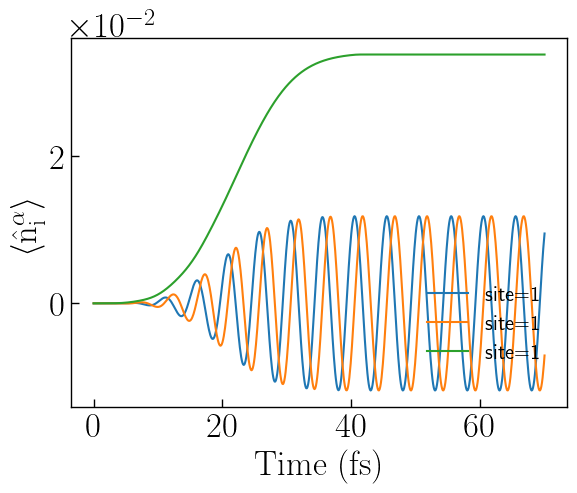

PyObject <matplotlib.legend.Legend object at 0x7f28d00ce450>

In [120]:

fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,6)
# for i in site 
#     axs.plot(ts_cd, cden_ta1[:,i]*det,label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
#     axs.plot(ts_cd, cden_ta1[:,i+1]*det,label= "site=$(i+1)")#
# end
axs.plot(sol.t, sd[:,1],label= "site=$(1)")#,alpha =1-0.2*i ) ### Charge bound current
axs.plot(sol.t, sd[:,2],label= "site=$(1)")
axs.plot(sol.t, sd[:,3],label= "site=$(1)")
#axs.plot(sol.t, -cd[:,3],label= "site=$(1)",ls = "--")#
#axs.plot(sol.t, cd[:,3].+cd[:,4],label= "site=$(2)")

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.axhline(0.035)
#plt.xlim(0,1)
#plt.xlim(100,120)
#plt.ylim(-0.02,0.02)
#plt.axhline(0.5,ls = "--",color="gray",lw = 0.5)

### Local density 

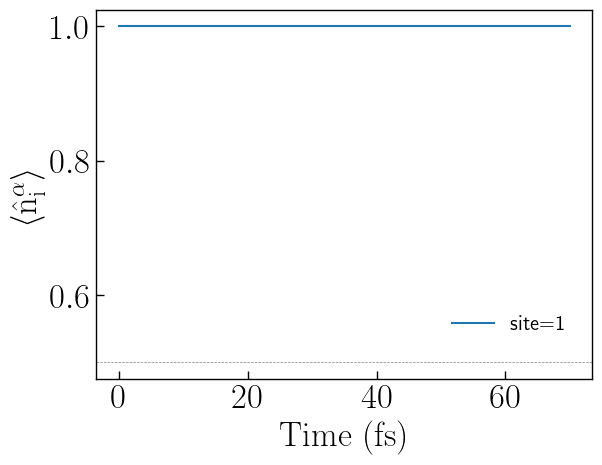

PyObject <matplotlib.lines.Line2D object at 0x7f28d083b050>

In [121]:

fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,6)
# for i in site 
#     axs.plot(ts_cd, cden_ta1[:,i]*det,label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
#     axs.plot(ts_cd, cden_ta1[:,i+1]*det,label= "site=$(i+1)")#
# end
axs.plot(sol.t, cd[:,1]+ cd[:,2],label= "site=$(1)")#,alpha =1-0.2*i ) ### Charge bound current
#axs.plot(sol.t, -cd[:,3],label= "site=$(1)",ls = "--")#
#axs.plot(sol.t, cd[:,3].+cd[:,4],label= "site=$(2)")

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(100,120)
#plt.xlim(0,20)
plt.axhline(0.5,ls = "--",color="gray",lw = 0.5)
#plt.xlim(0,20)
#plt.ylim(1-0.1,1+0.1)

In [88]:
#cc[:,1]


### Charge current 

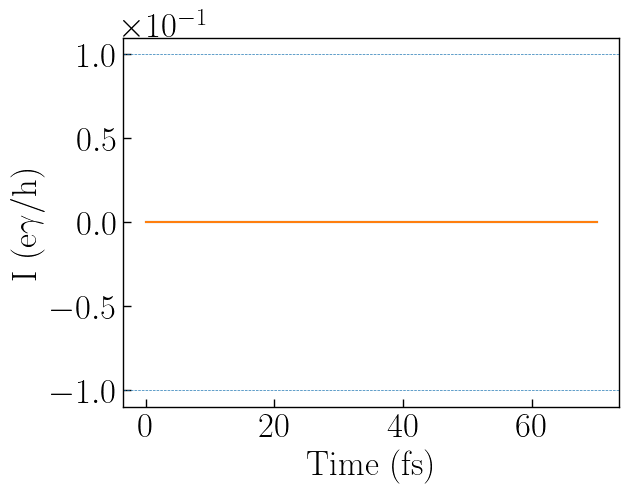

In [122]:
fig,axs = plt.subplots(1,1)

plt.plot(sol.t, cc[:,1])
plt.plot(sol.t, cc[:,2])
axs.set_ylabel(L"$\mathrm{I\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
#plt.xlim(30,80)
plt.axhline(0.1,ls = "--",lw=0.5)
plt.axhline(-0.1,ls = "--",lw=0.5)
#plt.axhline(0.0,ls = "--",lw=0.5)
#plt.axhline(0.05,ls = "--",lw=0.5)
#plt.ylim(-2,6.5)
#plt.xlim(0,12)
plt.show()
#plt.ylim(-0.05,0.05)
#plt.ylim(-1.2,1.2)
#plt.ylim(0.1-1e-2,0.1+1e-2)
#plt.xlim(110,120)

### Spin current

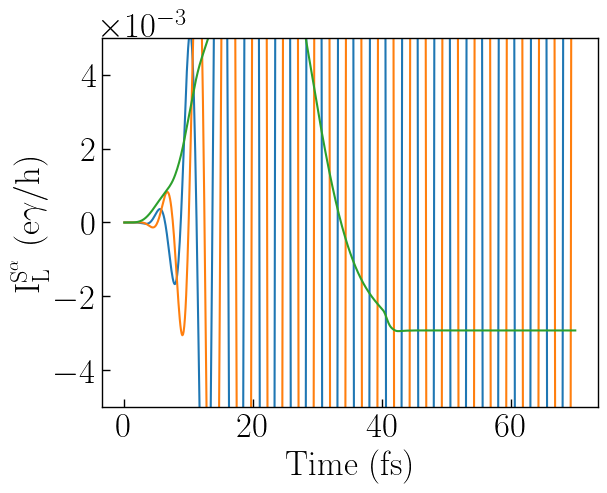

(-0.005, 0.005)

In [123]:
fig,axs = plt.subplots(1,1)

plt.plot(sol.t, sc[:,1])
plt.plot(sol.t, sc[:,2])
plt.plot(sol.t, sc[:,3])
axs.set_ylabel(L"$\mathrm{I_L^{S^{\alpha}}\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
plt.ylim(-0.005,0.005)
#plt.xlim(0,5)

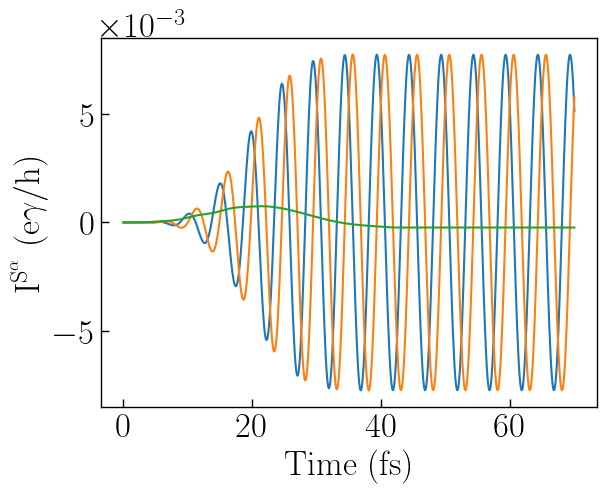

PyObject <matplotlib.legend.Legend object at 0x7f28d0789010>

In [124]:
fig,axs = plt.subplots(1,1)

plt.plot(sol.t, C_l_x)
plt.plot(sol.t, C_l_y)
plt.plot(sol.t, C_l_z)
axs.set_ylabel(L"$\mathrm{I^{S^{\alpha}}\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
#plt.ylim(-0.001,0.001)

In [201]:


# using DelimitedFiles
# cc_f = open("/home/jalil2/Documents/KBA/data/curr_KBE_jl.txt", "w+") 

# writedlm(cc_f, [sol.t Curr_left], ' ' )

# close(cc_f)

In [202]:
# using DelimitedFiles
# ccL_f = open("./data/ccL_KBE_jl.txt", "w+") 
# ccR_f = open("./data/ccR_KBE_jl.txt", "w+") 
# writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
# writedlm(ccR_f, [sol.t*hbar 4pi*Curr_right], ' ' )
# close(ccL_f)
# close(ccR_f)

In [203]:
#sol.t*hbar
#[sol.t*hbar  4pi*Curr_left]

In [55]:
#4pi*Curr_left[end]/0.05

In [121]:
#4pi*Curr_left[end]

In [122]:
#0.1/0.05
#0.096742516300053/0.05

In [37]:
#plt.plot(sol.t, Curr_right)

In [57]:
#0.05/0.2

## Save data 

In [125]:
using DelimitedFiles
path = "/home/jalil2/Documents/KBA/data"
name = "KBE_WBL_44";

### Spin density 

In [126]:
sd_f = open("$(path)/sd_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(sd_f, [sol.t sd], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(sd_f)

### Spin current

In [127]:
sc_f = open("$(path)/sc_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(sc_f, [sol.t sc], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(sc_f)

### Charge current 

In [128]:
#ccL_f = open("./data/ccL_GKBA_jl.txt", "w+") 
cc_f = open("$(path)/cc_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(cc_f, [sol.t cc], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(cc_f)

### Local density 

In [47]:
cden_f = open("$(path)/cd_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(cden_f, [sol.t cd], ' ' )
#close(ccL_f)
close(cden_f)